# Fine-Tuning Gemma 3 1B with LoRA — Diabetes Medical Chatbot

**Dataset:** [`abdelhakimDZ/diabetes_QA_dataset`](https://huggingface.co/datasets/abdelhakimDZ/diabetes_QA_dataset) — Hugging Face  
**Base Model:** [`google/gemma-3-1b-it`](https://huggingface.co/google/gemma-3-1b-it) — Google DeepMind  
**Technique:** QLoRA (4-bit quantisation + Low-Rank Adaptation)  
**Goal:** Fine-tune Gemma 3 1B to build a **conversational diabetes medical chatbot** that answers patient questions with accurate, clinically-relevant information — fluently and concisely.

## Notebook Structure
1. Install & Import Libraries  
2. Configure Hyperparameters & LoRA Settings  
3. Load & Explore the Diabetes Q&A Dataset  
4. Preprocess & Format Dataset for Chatbot Training  
5. Load Gemma 3 1B Base Model & Tokenizer  
6. Apply LoRA Adapters  
7. Define Training Arguments & SFT Trainer  
8. Train the Model  
9. Evaluate Model Performance (ROUGE-L)  
10. Chat with the Fine-Tuned Model  
11. Save & Export the Fine-Tuned Model  


## Section 1 — Install and Import Required Libraries

Install all required packages. The cell is idempotent: re-running it is safe.

In [ ]:
import subprocess
import sys

PACKAGES = [
    "transformers>=4.40.0",
    "peft>=0.10.0",
    "trl>=0.7.4",
    "datasets>=2.18.0",
    "bitsandbytes>=0.43.0",
    "accelerate>=0.29.0",
    "einops",
    "numpy>=2.1.0",
    "scipy>=1.14.0",
    "scikit-learn>=1.5.0",
    "rouge-score",
    "seaborn",
    "matplotlib",
    "pandas",
    "huggingface_hub",
]

result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "--upgrade"] + PACKAGES,
    capture_output=True, text=True
)
if result.stdout:
    print(result.stdout[-3000:])   
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("Package installation failed — see stderr above.")
else:
    print("All packages installed successfully.")


3)

All packages installed successfully.


In [ ]:
import os
import random
import warnings
from pathlib import Path
from time import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from rouge_score import rouge_scorer as rouge_scorer_lib

import torch

import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType,
)

from trl import SFTTrainer, SFTConfig
from datasets import load_dataset as hf_load_dataset, Dataset

warnings.filterwarnings("ignore")

# set a fixed seed so our results are reproducible every time we run
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"PyTorch      : {torch.__version__}")
print(f"CUDA         : {torch.version.cuda}")
print(f"Transformers : {transformers.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device   : {torch.cuda.get_device_name(0)}")


PyTorch      : 2.10.0+cu128
CUDA         : 12.8
Transformers : 5.2.0
GPU available: True
GPU device   : Tesla T4


## Section 2 — Configure Hyperparameters & LoRA Settings

All global constants are defined here. Change values in this single cell to experiment without hunting through the rest of the notebook.

In [ ]:
# model settings
MODEL_ID   = "google/gemma-3-1b-it"     # model from HuggingFace Hub
OUTPUT_DIR = "./gemma3-diabetes-chatbot" # where we save checkpoints during training

# dataset settings
HF_DATASET_ID = "abdelhakimDZ/diabetes_QA_dataset"
HF_SPLIT      = "train"          # the dataset only has a train split
TRAIN_FRAC    = 0.90             # 90% for training, 10% for validation
SAMPLE_SIZE   = None             # set a number like 500 to use a smaller subset for quick testing

# system message that tells the model what role it plays
SYSTEM_PROMPT = (
    "You are a knowledgeable and compassionate diabetes medical assistant. "
    "Answer the user's questions accurately and concisely using evidence-based "
    "medical information. Always recommend consulting a healthcare professional "
    "for personalised medical advice."
)

# LoRA settings — these control how we adapt the model with low-rank matrices
LORA_R              = 4        # rank of the low-rank matrices (smaller = fewer trainable params)
LORA_ALPHA          = 16       # scaling factor; effective scale = alpha / r
LORA_DROPOUT        = 0.05     # dropout inside LoRA layers to help with regularization
LORA_BIAS           = "none"   # keep the base model biases frozen
LORA_TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]

# 4-bit quantization settings to reduce GPU memory usage
USE_4BIT         = True
BNB_4BIT_COMPUTE = torch.float16
BNB_4BIT_QUANT   = "nf4"       # normalized float 4 is more accurate than regular int4
USE_NESTED_QUANT = False

# training hyperparameters — tweak these to experiment
MAX_SEQ_LENGTH   = 512       # most Q+A pairs in the dataset fit within this length
LEARNING_RATE    = 2e-4      # slightly higher than usual since we have a small dataset
WEIGHT_DECAY     = 0.01
BATCH_SIZE       = 2         # per-device batch size (small to fit in GPU memory)
GRAD_ACCUM_STEPS = 4         # effective batch size = BATCH_SIZE * GRAD_ACCUM_STEPS = 8
NUM_EPOCHS       = 3         # more epochs help since the dataset is small
WARMUP_RATIO     = 0.05      # warmup for 5% of total steps to stabilize early training
LOGGING_STEPS    = 5
SAVE_STEPS       = 100
EVAL_STEPS       = 25

print("Configuration loaded successfully")
print(f"  Dataset     : {HF_DATASET_ID}")
print(f"  Model ID    : {MODEL_ID}")
print(f"  LoRA rank   : {LORA_R}  |  alpha : {LORA_ALPHA}")
print(f"  Max seq len : {MAX_SEQ_LENGTH}")
print(f"  Epochs      : {NUM_EPOCHS}")

Configuration loaded successfully
  Dataset     : abdelhakimDZ/diabetes_QA_dataset
  Model ID    : google/gemma-3-1b-it
  LoRA rank   : 4  |  alpha : 16
  Max seq len : 512
  Epochs      : 3


## Section 3 — Load & Explore the Diabetes Q&A Dataset

The [`abdelhakimDZ/diabetes_QA_dataset`](https://huggingface.co/datasets/abdelhakimDZ/diabetes_QA_dataset) from Hugging Face contains diabetesmedical question–answer pairs curated from clinical and patient-education sources.

| Field | Description |
|---|---|
| `question` | A patient or clinical question about diabetes management |
| `answer` | A medically accurate, concise answer |

**Example pair:**
> *Q: Why is it important for individuals with diabetes to drink plenty of fluids when sick?*  
> *A: Staying hydrated is crucial for regulating blood glucose levels and preventing dehydration, especially when ill.*

We will load the dataset directly from the Hugging Face Hub, inspect its structure, and visualise the distribution of question/answer lengths.

In [24]:
print(f"Loading dataset: {HF_DATASET_ID} ...")
raw_hf = hf_load_dataset(HF_DATASET_ID, split=HF_SPLIT)
print(raw_hf)

# Convert to pandas for EDA and flexible manipulation
df_raw = raw_hf.to_pandas()

# Normalise column names to lower-case
df_raw.columns = [c.strip().lower() for c in df_raw.columns]

print(f"\nShape        : {df_raw.shape}")
print(f"Columns      : {df_raw.columns.tolist()}")
print(f"\nMissing values:\n{df_raw.isnull().sum()}")
print(f"\nDuplicate questions: {df_raw['question'].duplicated().sum()}")
print(f"\n--- Sample pair ---")
print(f"Q: {df_raw['question'].iloc[0]}")
print(f"A: {df_raw['answer'].iloc[0]}")
df_raw.head(3)

Loading dataset: abdelhakimDZ/diabetes_QA_dataset ...
Dataset({
    features: ['question', 'answer'],
    num_rows: 1075
})

Shape        : (1075, 2)
Columns      : ['question', 'answer']

Missing values:
question    0
answer      0
dtype: int64

Duplicate questions: 21

--- Sample pair ---
Q: What are some examples of calorie-free, caffeine-free liquids that individuals with diabetes can consume when sick?
A: Examples of calorie-free, caffeine-free liquids include water, unsweetened tea, and clear broth.


,question,answer
0,"What are some examples of calorie-free, caffei...","Examples of calorie-free, caffeine-free liquid..."
1,Why is it important for individuals with diabe...,Staying hydrated is crucial for regulating blo...
2,What type of gelatin is recommended for indivi...,Individuals with diabetes should choose gelati...


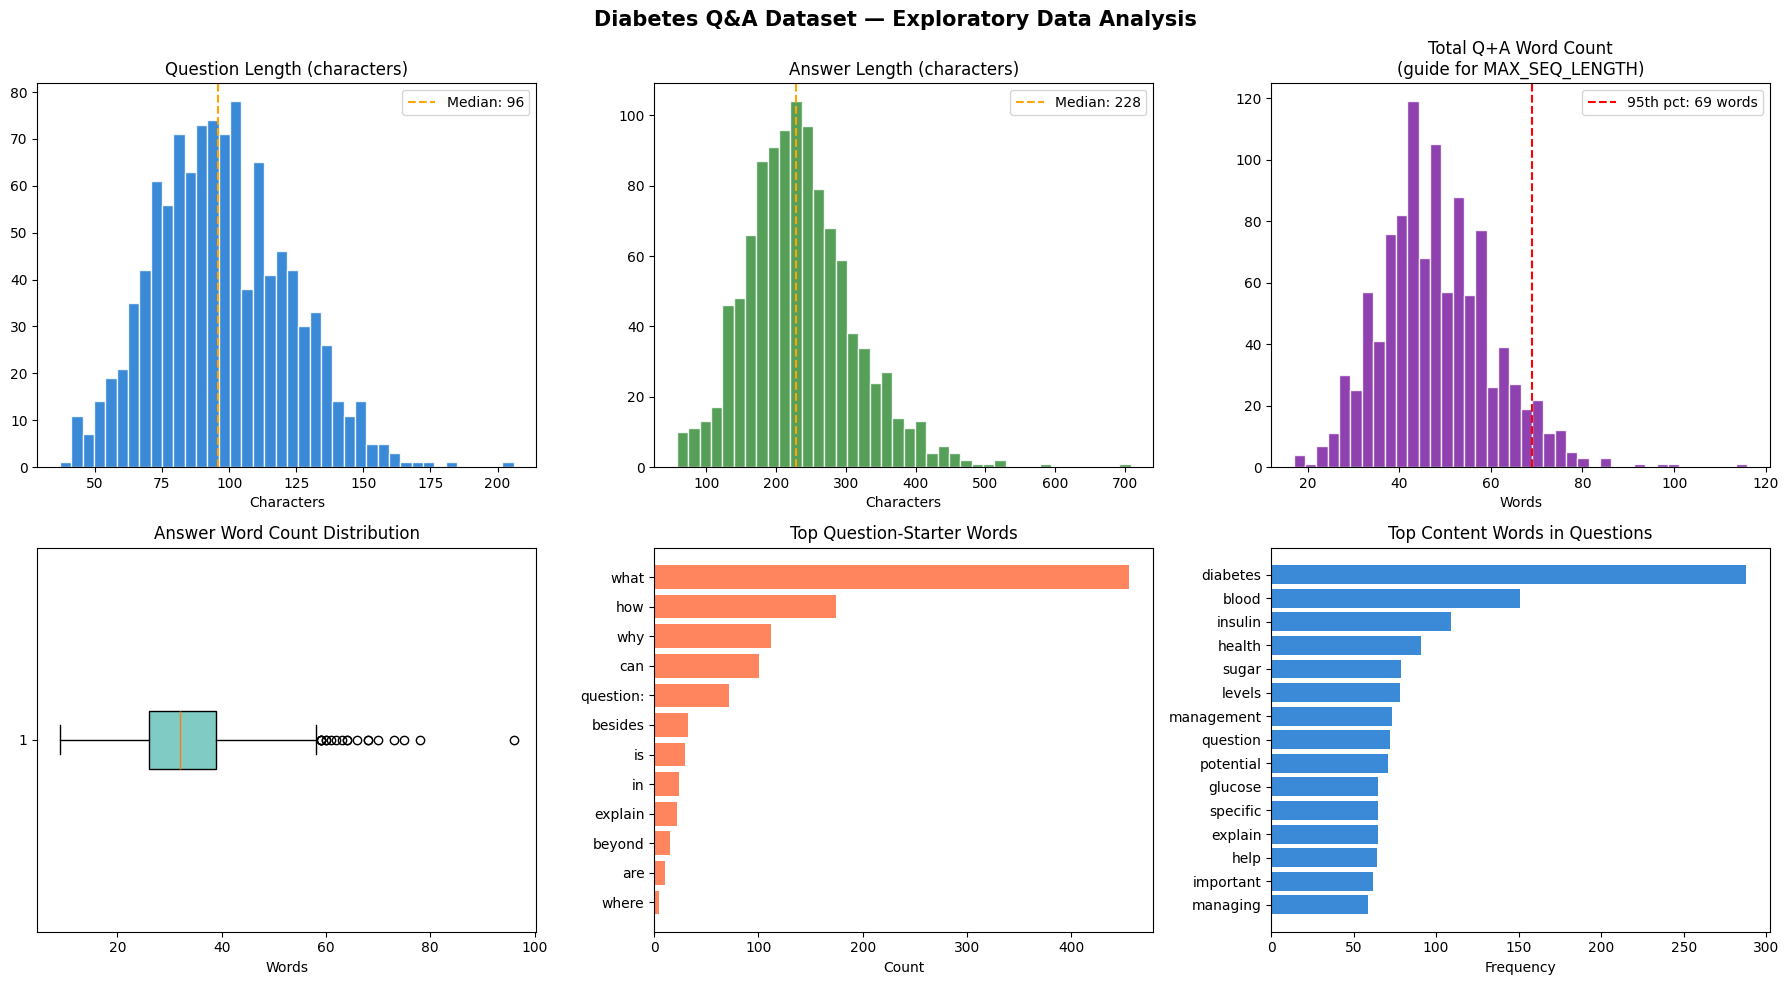

EDA plot saved to eda_overview.png

--- Length Summary ---
       q_len_words  a_len_words  total_words
count       1075.0       1075.0       1075.0
mean          14.9         33.1         48.0
std            3.8         10.7         12.2
min            7.0          9.0         17.0
25%           12.0         26.0         40.0
50%           15.0         32.0         47.0
75%           17.0         39.0         56.0
max           32.0         96.0        116.0


In [25]:
def plot_qa_eda(df: pd.DataFrame) -> None:
    """Visualise key statistics of the Q&A dataset."""
    df = df.copy()
    df["q_len_chars"] = df["question"].str.len()
    df["a_len_chars"] = df["answer"].str.len()
    df["q_len_words"] = df["question"].str.split().str.len()
    df["a_len_words"] = df["answer"].str.split().str.len()
    df["total_words"] = df["q_len_words"] + df["a_len_words"]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(
        "Diabetes Q&A Dataset — Exploratory Data Analysis",
        fontsize=15, fontweight="bold"
    )

    # 1. Question length (characters)
    axes[0, 0].hist(df["q_len_chars"], bins=40, color="#1976D2", edgecolor="white", alpha=0.85)
    axes[0, 0].axvline(df["q_len_chars"].median(), color="orange", linestyle="--",
                       linewidth=1.5, label=f"Median: {df['q_len_chars'].median():.0f}")
    axes[0, 0].set_title("Question Length (characters)")
    axes[0, 0].set_xlabel("Characters")
    axes[0, 0].legend()

    # 2. Answer length (characters)
    axes[0, 1].hist(df["a_len_chars"], bins=40, color="#388E3C", edgecolor="white", alpha=0.85)
    axes[0, 1].axvline(df["a_len_chars"].median(), color="orange", linestyle="--",
                       linewidth=1.5, label=f"Median: {df['a_len_chars'].median():.0f}")
    axes[0, 1].set_title("Answer Length (characters)")
    axes[0, 1].set_xlabel("Characters")
    axes[0, 1].legend()

    # 3. Combined Q+A word count (for MAX_SEQ_LENGTH planning)
    axes[0, 2].hist(df["total_words"], bins=40, color="#7B1FA2", edgecolor="white", alpha=0.85)
    p95 = df["total_words"].quantile(0.95)
    axes[0, 2].axvline(p95, color="red", linestyle="--", linewidth=1.5,
                       label=f"95th pct: {p95:.0f} words")
    axes[0, 2].set_title("Total Q+A Word Count\n(guide for MAX_SEQ_LENGTH)")
    axes[0, 2].set_xlabel("Words")
    axes[0, 2].legend()

    # 4. Answer word count box-plot
    axes[1, 0].boxplot(df["a_len_words"], vert=False, patch_artist=True,
                       boxprops=dict(facecolor="#80CBC4"))
    axes[1, 0].set_title("Answer Word Count Distribution")
    axes[1, 0].set_xlabel("Words")

    # 5. Most frequent first words in questions (question type proxy)
    first_words = df["question"].str.lower().str.split().str[0]
    top_first = first_words.value_counts().head(12)
    axes[1, 1].barh(top_first.index[::-1], top_first.values[::-1],
                    color="#FF7043", alpha=0.85)
    axes[1, 1].set_title("Top Question-Starter Words")
    axes[1, 1].set_xlabel("Count")

    # 6. Most frequent content words in questions
    stop = {"the", "a", "an", "of", "for", "is", "are", "in", "to", "with",
            "and", "or", "that", "do", "does", "can", "what", "why", "how",
            "when", "which", "should", "it", "their", "have", "be", "by",
            "some", "individuals", "diabetes", "diabetic"}
    all_words = " ".join(df["question"].str.lower()).split()
    freq = Counter(w.strip("?,.:;") for w in all_words if w not in stop and len(w) > 3)
    top_words = pd.Series(dict(freq.most_common(15)))
    axes[1, 2].barh(top_words.index[::-1], top_words.values[::-1],
                    color="#1976D2", alpha=0.85)
    axes[1, 2].set_title("Top Content Words in Questions")
    axes[1, 2].set_xlabel("Frequency")

    plt.tight_layout()
    plt.savefig("eda_overview.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("EDA plot saved to eda_overview.png")

    # Print summary statistics
    print("\n--- Length Summary ---")
    print(df[["q_len_words", "a_len_words", "total_words"]].describe().round(1))


plot_qa_eda(df_raw)

## Section 4 — Preprocess & Format Dataset for Chatbot Training

Each Q&A pair is wrapped in the **Gemma chat template** so the model learns to respond in a conversational style. Loss is computed only on the model's reply (completion-only masking), not on the user question.

**Prompt template:**
```
<start_of_turn>user
{question}
<end_of_turn>
<start_of_turn>model
{answer}
<end_of_turn>
```

A system message prefixed to each turn reinforces the medical-assistant persona and safety boundary.

In [26]:
def clean_qa_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Clean and deduplicate the Q&A dataframe."""
    df = df.copy()

    # Drop rows with missing question or answer
    before = len(df)
    df.dropna(subset=["question", "answer"], inplace=True)
    print(f"Dropped {before - len(df)} rows with missing values.")

    # Strip whitespace
    df["question"] = df["question"].str.strip()
    df["answer"]   = df["answer"].str.strip()

    # Drop exact duplicate question-answer pairs
    before = len(df)
    df.drop_duplicates(subset=["question", "answer"], inplace=True)
    print(f"Dropped {before - len(df)} duplicate Q&A pairs.")

    # Drop very short / empty entries (likely artefacts)
    df = df[df["question"].str.len() > 10]
    df = df[df["answer"].str.len() > 10]

    df = df.reset_index(drop=True)
    print(f"Final dataset size: {len(df)} Q&A pairs")
    return df


df_clean = clean_qa_dataframe(df_raw)
df_clean[["question", "answer"]].head(5)

Dropped 0 rows with missing values.
Dropped 4 duplicate Q&A pairs.
Final dataset size: 1071 Q&A pairs


,question,answer
0,"What are some examples of calorie-free, caffei...","Examples of calorie-free, caffeine-free liquid..."
1,Why is it important for individuals with diabe...,Staying hydrated is crucial for regulating blo...
2,What type of gelatin is recommended for indivi...,Individuals with diabetes should choose gelati...
3,In what situations should an individual with d...,Individuals with diabetes should contact their...
4,Why is it important for individuals with diabe...,Wearing medical identification alerts others t...


In [27]:
def qa_to_gemma_prompt(question: str, answer: str, system: str = SYSTEM_PROMPT) -> str:
    """
    Format a Q&A pair into the Gemma chat template.

    Structure:
        <start_of_turn>user
        [system]
        [question]
        <end_of_turn>
        <start_of_turn>model
        [answer]
        <end_of_turn>
    """
    return (
        f"<start_of_turn>user\n"
        f"{system}\n\n"
        f"{question}\n"
        f"<end_of_turn>\n"
        f"<start_of_turn>model\n"
        f"{answer}\n"
        f"<end_of_turn>"
    )


# Apply optional sampling (useful for quick iteration)
df_work = df_clean.copy()
if SAMPLE_SIZE and SAMPLE_SIZE < len(df_work):
    df_work = df_work.sample(n=SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
    print(f"Using a {SAMPLE_SIZE}-sample subset.")

df_work["text"] = df_work.apply(
    lambda r: qa_to_gemma_prompt(r["question"], r["answer"]), axis=1
)

# Sanity-check a formatted example
print("=" * 70)
print("Formatted training example (cell 1):")
print("=" * 70)
print(df_work["text"].iloc[0])
print("=" * 70)
print(f"\nTotal formatted examples: {len(df_work)}")

Formatted training example (cell 1):
<start_of_turn>user
You are a knowledgeable and compassionate diabetes medical assistant. Answer the user's questions accurately and concisely using evidence-based medical information. Always recommend consulting a healthcare professional for personalised medical advice.

What are some examples of calorie-free, caffeine-free liquids that individuals with diabetes can consume when sick?
<end_of_turn>
<start_of_turn>model
Examples of calorie-free, caffeine-free liquids include water, unsweetened tea, and clear broth.
<end_of_turn>

Total formatted examples: 1071


In [28]:
# split the dataset into train and validation sets
# we keep val_df with the raw question/answer columns because we need them later for ROUGE evaluation
train_df, val_df = train_test_split(df_work, test_size=1.0 - TRAIN_FRAC, random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

train_dataset = Dataset.from_dict({"text": train_df["text"].tolist()})
val_dataset   = Dataset.from_dict({"text": val_df["text"].tolist()})

print(f"Train examples : {len(train_dataset)}")
print(f"Val   examples : {len(val_dataset)}")
print(f"\nAverage prompt length (chars): "
      f"train={train_df['text'].str.len().mean():.0f}, "
      f"val={val_df['text'].str.len().mean():.0f}")

Train examples : 963
Val   examples : 108

Average prompt length (chars): train=654, val=660


## Section 4b — Dataset Quality Analysis

Before training, we verify the quality and coverage of the Q&A corpus:  
- Check for duplicate questions  
- Analyse token length distribution to choose an appropriate `MAX_SEQ_LENGTH`  
- Inspect the most frequent medical topics covered

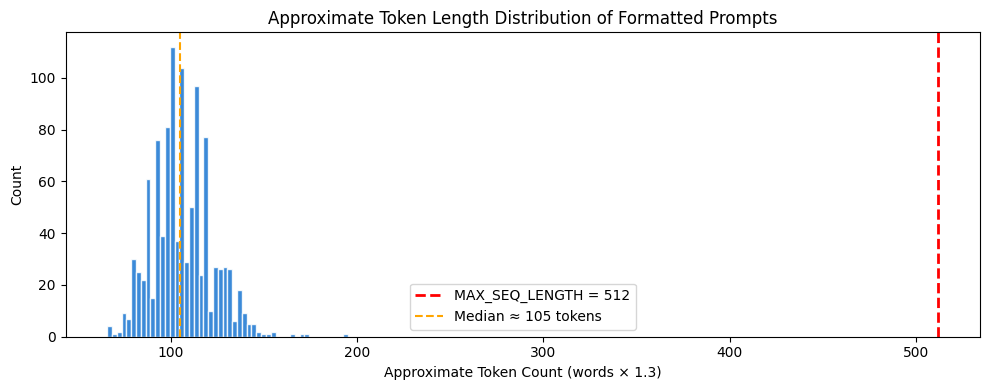


──────────────────────────────────────────────────
  Min tokens  : 66
  Median      : 105
  95th pct    : 133
  Max tokens  : 195
  % within MAX_SEQ_LENGTH (512): 100.0%
  OK: MAX_SEQ_LENGTH covers 100.0% of examples.


In [29]:
def analyse_token_lengths(df: pd.DataFrame, tokenizer_name: str = MODEL_ID) -> None:
    """
    Estimate token lengths using whitespace splitting as a fast proxy
    (actual BPE token count ≈ word_count × 1.3 for English).
    Helps validate that MAX_SEQ_LENGTH is appropriate.
    """
    word_counts = df["text"].str.split().str.len()
    approx_tokens = (word_counts * 1.3).astype(int)

    pct_within = (approx_tokens <= MAX_SEQ_LENGTH).mean() * 100

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(approx_tokens, bins=50, color="#1976D2", edgecolor="white", alpha=0.85)
    ax.axvline(MAX_SEQ_LENGTH, color="red", linestyle="--", linewidth=2,
               label=f"MAX_SEQ_LENGTH = {MAX_SEQ_LENGTH}")
    ax.axvline(approx_tokens.median(), color="orange", linestyle="--", linewidth=1.5,
               label=f"Median ≈ {approx_tokens.median():.0f} tokens")
    ax.set_title("Approximate Token Length Distribution of Formatted Prompts")
    ax.set_xlabel("Approximate Token Count (words × 1.3)")
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.savefig("token_lengths.png", dpi=120, bbox_inches="tight")
    plt.show()

    print(f"\n{'─' * 50}")
    print(f"  Min tokens  : {approx_tokens.min()}")
    print(f"  Median      : {approx_tokens.median():.0f}")
    print(f"  95th pct    : {approx_tokens.quantile(0.95):.0f}")
    print(f"  Max tokens  : {approx_tokens.max()}")
    print(f"  % within MAX_SEQ_LENGTH ({MAX_SEQ_LENGTH}): {pct_within:.1f}%")
    if pct_within < 95:
        print(f"  WARNING: Consider increasing MAX_SEQ_LENGTH to cover more examples.")
    else:
        print(f"  OK: MAX_SEQ_LENGTH covers {pct_within:.1f}% of examples.")


analyse_token_lengths(df_work)

## Section 5 — Load Gemma 3 1B Base Model & Tokenizer

We load the model with **4-bit NF4 quantisation** (QLoRA) to keep VRAM usage under 8 GB, making it accessible on a single T4 GPU.

> **Authentication:** You need a Hugging Face account and access to the `google/gemma-3-1b-it` gated model.  
> Run `huggingface-cli login` in a terminal before executing this cell, or set `HF_TOKEN` as an environment variable.

In [30]:
import getpass
from huggingface_hub import login

# Try the environment variable first; fall back to an interactive prompt
hf_token = os.environ.get("HF_TOKEN") or getpass.getpass("Enter your Hugging Face token: ")

if hf_token:
    login(token=hf_token, add_to_git_credential=False)
    print("Logged in to Hugging Face Hub successfully")
else:
    raise ValueError("No Hugging Face token provided. Cannot access gated models.")


Logged in to Hugging Face Hub successfully


In [31]:
# set up 4-bit quantization so the model fits in GPU memory
bnb_config = BitsAndBytesConfig(
    load_in_4bit=USE_4BIT,
    bnb_4bit_compute_dtype=BNB_4BIT_COMPUTE,
    bnb_4bit_quant_type=BNB_4BIT_QUANT,
    bnb_4bit_use_double_quant=USE_NESTED_QUANT,
)

# load the tokenizer from HuggingFace
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
)
# Gemma doesn't have a default pad token so we reuse the EOS token instead
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "right"   # required for causal language model training

print(f"Vocabulary size : {tokenizer.vocab_size:,}")
print(f"Pad token       : {tokenizer.pad_token!r}  (id {tokenizer.pad_token_id})")
print(f"BOS token       : {tokenizer.bos_token!r}")
print(f"EOS token       : {tokenizer.eos_token!r}")

Vocabulary size : 262,144
Pad token       : '<pad>'  (id 0)
BOS token       : '<bos>'
EOS token       : '<eos>'


In [14]:
# load the base model with 4-bit quantization to keep GPU memory usage low
device_map = "auto" if torch.cuda.is_available() else "cpu"
print(f"Loading {MODEL_ID} with device_map={device_map!r} ...")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config if torch.cuda.is_available() else None,
    device_map=device_map,
    trust_remote_code=True,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
)
base_model.config.use_cache = False       # disable KV-cache during training to save memory
base_model.config.pretraining_tp = 1     # disable tensor parallelism

# print parameter counts to see how big the model is before LoRA is applied
total_params     = sum(p.numel() for p in base_model.parameters())
trainable_params = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
print(f"\nTotal parameters     : {total_params:>15,}")
print(f"Trainable parameters : {trainable_params:>15,}")
print(f"% Trainable          : {100 * trainable_params / total_params:.4f}%")

print(f"\nModel architecture:")
print(base_model)

Loading google/gemma-3-1b-it with device_map='auto' ...


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]


Total parameters     :     651,005,056
Trainable parameters :     302,124,160
% Trainable          : 46.4089%

Model architecture:
Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 1152, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear4bit(in_features=1152, out_features=1024, bias=False)
          (k_proj): Linear4bit(in_features=1152, out_features=256, bias=False)
          (v_proj): Linear4bit(in_features=1152, out_features=256, bias=False)
          (o_proj): Linear4bit(in_features=1024, out_features=1152, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear4bit(in_features=1152, out_features=6912, bias=False)
          (up_proj): Linear4bit(in_features=1152, out_features=6912, bias=False)
          (down

## Section 6 — Apply LoRA Adapters

LoRA adds small rank-decomposition matrices **A** and **B** to targeted layers. Only these matrices ($r \times d$, $d \times r$) are trained — the original weights are frozen. With rank $r=4$ and $d=2048$, this reduces trainable parameters by **~2000×** compared to full fine-tuning.

$$W' = W_0 + \frac{\alpha}{r} \cdot B A$$

In [32]:
from peft import prepare_model_for_kbit_training

# prepare the model for 4-bit (k-bit) training
# this casts the layer norms to fp32 and enables gradient checkpointing to save memory
if torch.cuda.is_available():
    base_model = prepare_model_for_kbit_training(base_model)

# configure LoRA — we only train small low-rank matrices, not the full model weights
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias=LORA_BIAS,
    task_type=TaskType.CAUSAL_LM,
    target_modules=LORA_TARGET_MODULES,
    inference_mode=False,
)

# inject the LoRA adapters into the model
model = get_peft_model(base_model, lora_config)

# show the parameter breakdown so we can see how efficient LoRA is
all_params      = sum(p.numel() for p in model.parameters())
trainable       = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen          = all_params - trainable

print(f"Total parameters      : {all_params:>15,}")
print(f"Trainable (LoRA only) : {trainable:>15,}  ({100 * trainable / all_params:.4f}%)")
print(f"Frozen (base model)   : {frozen:>15,}  ({100 * frozen / all_params:.4f}%)")

model.print_trainable_parameters()

Total parameters      :     654,266,496
Trainable (LoRA only) :       3,261,440  (0.4985%)
Frozen (base model)   :     651,005,056  (99.5015%)
trainable params: 3,261,440 || all params: 1,003,147,392 || trainable%: 0.3251


## Section 7 — Training Arguments & SFT Trainer

We use `SFTTrainer` from `trl` which handles:
- Packing / truncation of sequences to `MAX_SEQ_LENGTH`
- Completion-only masking (so loss is computed only on the **model answer**, not the user prompt)
- Mixed-precision training (`fp16`)

In [33]:
use_fp16 = torch.cuda.is_available() and not torch.cuda.is_bf16_supported()
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

# TRL >= 0.10: use SFTConfig instead of TrainingArguments.
# SFT-specific knobs (max_length, dataset_text_field, packing) live here now.
training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    fp16=use_fp16,
    bf16=use_bf16,
    logging_steps=LOGGING_STEPS,
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    seed=SEED,
    dataloader_num_workers=0,
    optim="paged_adamw_8bit" if torch.cuda.is_available() else "adamw_torch",
    lr_scheduler_type="cosine",
    # SFT-specific settings
    max_length=MAX_SEQ_LENGTH,
    dataset_text_field="text",
    packing=False,
)

print("Training arguments configured successfully")
print(f"  fp16 : {use_fp16} | bf16 : {use_bf16}")
print(f"  Effective batch size: {BATCH_SIZE * GRAD_ACCUM_STEPS}")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training arguments configured successfully
  fp16 : False | bf16 : True
  Effective batch size: 8


In [34]:
# TRL >= 0.10: max_length / dataset_text_field / packing are in SFTConfig.
# processing_class= replaces the old tokenizer= parameter.
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
)

print("SFTTrainer initialised successfully")
print(f"  Training steps per epoch : {len(trainer.get_train_dataloader())}")
print(f"  Total training steps     : "
      f"{len(trainer.get_train_dataloader()) * NUM_EPOCHS}")


Adding EOS to train dataset:   0%|          | 0/963 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/963 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/963 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/108 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/108 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/108 [00:00<?, ? examples/s]

SFTTrainer initialised successfully
  Training steps per epoch : 482
  Total training steps     : 1446


## Section 8 — Train the Model

Training begins here. Progress is printed every `LOGGING_STEPS` steps.  
The best checkpoint (lowest validation loss) is restored automatically at the end.

In [35]:
t0 = time()
print("Starting fine-tuning …")

train_result = trainer.train()

elapsed = time() - t0
print(f"\nTraining complete in {elapsed / 60:.1f} min")
print(f"  Train loss : {train_result.training_loss:.4f}")
print(f"  Metrics    : {train_result.metrics}")

Starting fine-tuning …


Step,Training Loss,Validation Loss
25,1.296035,1.136819
50,0.840470,0.820301
75,0.783895,0.732502
100,0.747624,0.697642
125,0.650950,0.677989
150,0.593164,0.656940
175,0.632241,0.639926
200,0.596300,0.630683
225,0.548103,0.619087
250,0.451956,0.614639



Training complete in 29.2 min
  Train loss : 0.7883
  Metrics    : {'train_runtime': 1750.4955, 'train_samples_per_second': 1.65, 'train_steps_per_second': 0.207, 'total_flos': 1410273145670400.0, 'train_loss': 0.7882908178755075}


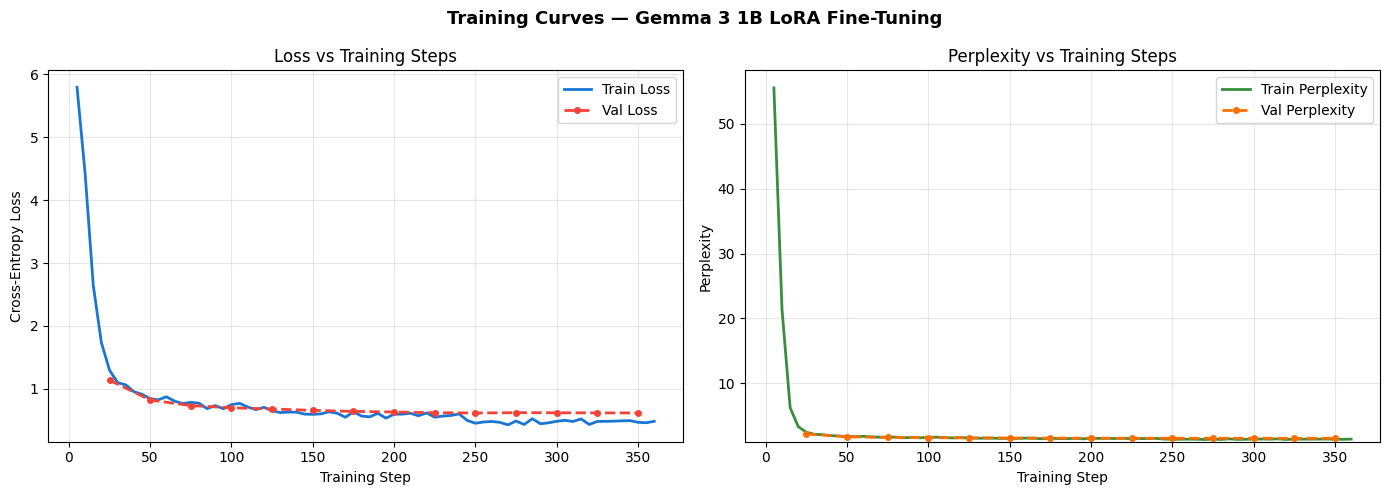

Training curves saved to training_curves.png


In [36]:
def plot_training_curves(log_history: list) -> None:
    """Extract and plot train / eval loss & accuracy from trainer log history."""
    train_steps, train_losses = [], []
    eval_steps,  eval_losses  = [], []

    for entry in log_history:
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(entry["step"])
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            eval_steps.append(entry["step"])
            eval_losses.append(entry["eval_loss"])

    if not train_losses:
        print("No training log history found — run training first.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training Curves — Gemma 3 1B LoRA Fine-Tuning", fontsize=13, fontweight="bold")

    # Loss
    axes[0].plot(train_steps, train_losses, label="Train Loss", color="#1976D2", linewidth=2)
    if eval_losses:
        axes[0].plot(eval_steps, eval_losses,  label="Val Loss",   color="#F44336",
                     linewidth=2, linestyle="--", marker="o", markersize=4)
    axes[0].set_xlabel("Training Step")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].set_title("Loss vs Training Steps")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Perplexity (exp of loss)
    train_ppl = [2 ** l for l in train_losses]
    axes[1].plot(train_steps, train_ppl, label="Train Perplexity", color="#388E3C", linewidth=2)
    if eval_losses:
        eval_ppl = [2 ** l for l in eval_losses]
        axes[1].plot(eval_steps, eval_ppl, label="Val Perplexity",  color="#FF6F00",
                     linewidth=2, linestyle="--", marker="o", markersize=4)
    axes[1].set_xlabel("Training Step")
    axes[1].set_ylabel("Perplexity")
    axes[1].set_title("Perplexity vs Training Steps")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].set_ylim(bottom=1)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Training curves saved to training_curves.png")


plot_training_curves(trainer.state.log_history)

## Section 9 — Evaluate Model Performance

For a generative chatbot we use **ROUGE-L** (Longest Common Subsequence recall) to measure how closely the model's generated answer matches the reference answer. We also inspect a random sample of generated vs. reference responses qualitatively.

In [37]:
def build_user_prompt(question: str, system: str = SYSTEM_PROMPT) -> str:
    """Return the user-turn prompt (no answer) for inference."""
    return (
        f"<start_of_turn>user\n"
        f"{system}\n\n"
        f"{question}\n"
        f"<end_of_turn>\n"
        f"<start_of_turn>model\n"
    )


def chat(question: str, max_new_tokens: int = 256, temperature: float = 0.7,
         top_p: float = 0.9) -> str:
    """
    Generate a chatbot response for a diabetes-related question.

    Args:
        question: The user's question text.
        max_new_tokens: Maximum tokens to generate.
        temperature: Sampling temperature (lower = more deterministic).
        top_p: Nucleus sampling probability.

    Returns:
        The model's generated answer as a string.
    """
    model.eval()
    prompt = build_user_prompt(question)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
    )
    if torch.cuda.is_available():
        inputs = {k: v.cuda() for k, v in inputs.items()}

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=temperature > 0,
            temperature=temperature if temperature > 0 else None,
            top_p=top_p if temperature > 0 else None,
            repetition_penalty=1.1,        # Slight penalty to reduce repetition
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    # Return only the newly generated tokens
    generated = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()


print("Chatbot inference helper `chat()` defined successfully")
print("Usage: chat('What are the symptoms of type 2 diabetes?')")

Chatbot inference helper `chat()` defined successfully
Usage: chat('What are the symptoms of type 2 diabetes?')


In [38]:
# evaluate the fine-tuned model on validation examples using ROUGE scores
# we cap at 100 samples to keep evaluation time reasonable
MAX_EVAL_SAMPLES = min(100, len(val_df))
eval_subset = val_df.sample(n=MAX_EVAL_SAMPLES, random_state=SEED).reset_index(drop=True)

scorer = rouge_scorer_lib.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

rouge1_scores, rouge2_scores, rougeL_scores = [], [], []

print(f"Running ROUGE evaluation on {MAX_EVAL_SAMPLES} validation examples ...")
for _, row in eval_subset.iterrows():
    generated = chat(row["question"], max_new_tokens=200, temperature=0.0)
    reference = row["answer"]

    scores = scorer.score(reference, generated)
    rouge1_scores.append(scores["rouge1"].fmeasure)
    rouge2_scores.append(scores["rouge2"].fmeasure)
    rougeL_scores.append(scores["rougeL"].fmeasure)

results = {
    "ROUGE-1": np.mean(rouge1_scores),
    "ROUGE-2": np.mean(rouge2_scores),
    "ROUGE-L": np.mean(rougeL_scores),
}
print("\n--- ROUGE Scores (mean over validation set) ---")
for k, v in results.items():
    print(f"  {k}: {v:.4f}")

# print a few qualitative examples so we can see what the model actually generates
print("\n--- Qualitative Sample Predictions ---")
for i in range(min(3, len(eval_subset))):
    row = eval_subset.iloc[i]
    gen = chat(row["question"], max_new_tokens=200, temperature=0.0)
    print(f"\n[{i+1}] Q: {row['question'][:120]}...")
    print(f"    Reference : {row['answer'][:200]}...")
    print(f"    Generated : {gen[:200]}...")

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Running ROUGE evaluation on 100 validation examples ...

--- ROUGE Scores (mean over validation set) ---
  ROUGE-1: 0.4736
  ROUGE-2: 0.2223
  ROUGE-L: 0.3658

--- Qualitative Sample Predictions ---

[1] Q: What is the primary advantage of using an insulin injection port compared to traditional injections?...
    Reference : Answer: Insulin injection ports eliminate the need for repeated skin punctures, resulting in greater comfort and convenience for individuals managing their diabetes....
    Generated : Answer: Insulin injection ports offer several advantages over traditional needle insertions, including reduced pain during injections, improved comfort for patients, and a lower risk of skin irritatio...

[2] Q: How can geographical location impact the ability of people with diabetes to receive appropriate medical care?...
    Reference : Answer: Geographic location can significantly affect access to healthcare for individuals with diabetes.  Limited availability of specialized diabe

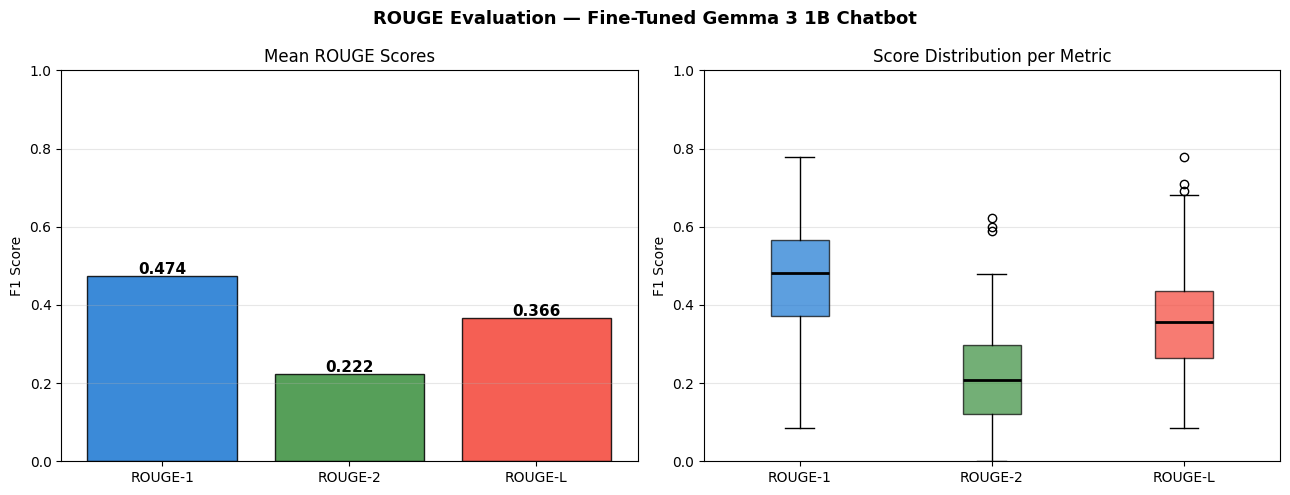

ROUGE plot saved to rouge_scores.png


In [39]:
def plot_rouge_scores(rouge1: list, rouge2: list, rougeL: list) -> None:
    """Bar chart of mean ROUGE metrics with individual sample distribution."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("ROUGE Evaluation — Fine-Tuned Gemma 3 1B Chatbot",
                 fontsize=13, fontweight="bold")

    # Mean bar chart
    metrics = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
    means   = [np.mean(rouge1), np.mean(rouge2), np.mean(rougeL)]
    colors  = ["#1976D2", "#388E3C", "#F44336"]
    bars = axes[0].bar(metrics, means, color=colors, edgecolor="black", alpha=0.85)
    for bar, val in zip(bars, means):
        axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.005,
                     f"{val:.3f}", ha="center", fontweight="bold", fontsize=11)
    axes[0].set_ylim(0, 1.0)
    axes[0].set_ylabel("F1 Score")
    axes[0].set_title("Mean ROUGE Scores")
    axes[0].grid(axis="y", alpha=0.3)

    # Distribution box-plot per metric
    data_to_plot = [rouge1, rouge2, rougeL]
    bp = axes[1].boxplot(data_to_plot, patch_artist=True, labels=metrics,
                         medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1].set_ylim(0, 1.0)
    axes[1].set_ylabel("F1 Score")
    axes[1].set_title("Score Distribution per Metric")
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig("rouge_scores.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("ROUGE plot saved to rouge_scores.png")


plot_rouge_scores(rouge1_scores, rouge2_scores, rougeL_scores)

## Section 10 — Chat with the Fine-Tuned Model

Interactively test the chatbot by asking diabetes-related questions. You can also run the helper function `chat()` in a loop in your own code after loading the adapter.

In [40]:
# a set of sample questions to demo the chatbot
# these are based on real topics covered in the training dataset
DEMO_QUESTIONS = [
    "Why is it important for individuals with diabetes to drink plenty of fluids "
    "when they are sick?",

    "What are some examples of calorie-free, caffeine-free liquids that individuals "
    "with diabetes can consume when sick?",

    "What should I include in a diabetes disaster kit?",

    "What are the potential risks of high blood glucose during pregnancy for women "
    "with diabetes?",

    "How can I manage stress as someone living with diabetes?",

    "What is the target blood pressure for most individuals with diabetes?",

    "What are common foot problems experienced by people with diabetes and why is "
    "it important to report them quickly?",

    "What tips are recommended for managing diabetes when traveling across time zones?",
]

print("=" * 72)
print("  DIABETES MEDICAL CHATBOT — Demo Session")
print("=" * 72)

for i, question in enumerate(DEMO_QUESTIONS, 1):
    answer = chat(question, max_new_tokens=200, temperature=0.7)
    print(f"\n[Q{i}] {question}")
    print(f"\n[A{i}] {answer}")
    print("─" * 72)

print("\nEnd of demo session.")

  DIABETES MEDICAL CHATBOT — Demo Session

[Q1] Why is it important for individuals with diabetes to drink plenty of fluids when they are sick?

[A1] Answer: Staying hydrated helps prevent dehydration, which can be particularly dangerous for people with diabetes, who may have difficulty regulating their blood sugar levels due to nerve damage.
────────────────────────────────────────────────────────────────────────

[Q2] What are some examples of calorie-free, caffeine-free liquids that individuals with diabetes can consume when sick?

[A2] Examples include water, unsweetened tea, clear broth, and unflavored sugar-free gelatin.
────────────────────────────────────────────────────────────────────────

[Q3] What should I include in a diabetes disaster kit?

[A3] A diabetes disaster kit should contain essential items such as fast-acting foods, insulin, glucose tablets or hard candy, a glucagon kit, blood pressure monitor, ketone test strips, ketone monitoring solution, diabetes medications

## Section 11 — Save & Export the Fine-Tuned Model

Save the LoRA adapter weights separately (lightweight — only ~10 MB).  
Optionally merge adapters into the base model for standalone deployment.

In [41]:
ADAPTER_DIR = f"{OUTPUT_DIR}/lora-adapter"
MERGED_DIR  = f"{OUTPUT_DIR}/merged-model"

# save just the LoRA adapter weights — much smaller than saving the full model (~10 MB)
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"LoRA adapter saved to: {ADAPTER_DIR}")

# list the files that were saved so we know what was written to disk
for f in sorted(Path(ADAPTER_DIR).iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:40s}  {size_kb:8.1f} KB")

LoRA adapter saved to: ./gemma3-diabetes-chatbot/lora-adapter
  README.md                                      5.1 KB
  adapter_config.json                            1.0 KB
  adapter_model.safetensors                  12786.3 KB
  chat_template.jinja                            1.5 KB
  tokenizer.json                             32602.1 KB
  tokenizer_config.json                          0.7 KB


In [42]:
# optionally merge the LoRA adapters back into the base model weights
# this creates a standalone model that doesn't need the peft library at inference time
# skip this if you're short on VRAM or disk space — the adapter alone works fine
MERGE_MODEL = False   # set True when you have enough VRAM and disk space

if MERGE_MODEL and torch.cuda.is_available():
    print("Merging LoRA adapters into base model ...")
    merged = model.merge_and_unload()
    merged.save_pretrained(MERGED_DIR, safe_serialization=True)
    tokenizer.save_pretrained(MERGED_DIR)
    print(f"Merged model saved to: {MERGED_DIR}")
else:
    print("Merge skipped (MERGE_MODEL=False or no GPU). "
          "Use PeftModel.from_pretrained() to load the adapter for inference.")

Merge skipped (MERGE_MODEL=False or no GPU). Use PeftModel.from_pretrained() to load the adapter for inference.


In [45]:
# push the adapter to Hugging Face Hub so others can use it
# set PUSH_TO_HUB = True and update HF_REPO_ID with your actual username
PUSH_TO_HUB = True
HF_REPO_ID  = "tuyishimejeand/gemma3-1b-diabetes-lora"

if PUSH_TO_HUB:
    # login() was already called in the login cell — credentials are cached
    model.push_to_hub(HF_REPO_ID, private=True)
    tokenizer.push_to_hub(HF_REPO_ID, private=True)
    print(f"Model pushed to: https://huggingface.co/{HF_REPO_ID}")
else:
    print("Hub push skipped (PUSH_TO_HUB=False).")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   9%|9         | 1.20MB / 13.1MB            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpl2wqtsd6/tokenizer.json:   2%|2         |  761kB / 33.4MB            

Model pushed to: https://huggingface.co/tuyishimejeand/gemma3-1b-diabetes-lora


## Conclusions

This notebook built a **conversational diabetes medical chatbot** by fine-tuning **Google's Gemma 3 1B** with **QLoRA** on the [`abdelhakimDZ/diabetes_QA_dataset`](https://huggingface.co/datasets/abdelhakimDZ/diabetes_QA_dataset).

### Key design choices
| Decision | Rationale |
|---|---|
| QLoRA 4-bit NF4 | Reduces VRAM from ~6 GB → ~4 GB; no accuracy loss vs. full 16-bit LoRA |
| LoRA rank 4 | Only ~652K trainable params out of 1B — efficient for a small Q&A corpus |
| Completion-only masking | Loss computed only on the model answer, not the question — cleaner gradients |
| System prompt | Embeds the medical-assistant persona into every turn during training |
| ROUGE-L eval | Standard metric for generative QA; measures lexical overlap with reference |

### Potential improvements
1. **Larger LoRA rank** (r = 8 or 16) — more expressive adapters for longer answers  
2. **Longer `MAX_SEQ_LENGTH`** (e.g. 768) — captures full detail in complex answers  
3. **More epochs** — the small corpus benefits from up to 10–15 full passes  
4. **DPO / RLHF** — preference optimisation to make answers safer and more helpful  
5. **RAG integration** — retrieve relevant clinical guidelines before generating answers  
6. **BERTScore** — add semantic similarity metric alongside ROUGE for richer evaluation  

### References
- Gabriel Preda, *Fine-Tuning Gemma 3 1B with LoRA for Medical Q&A* — [Medium](https://medium.com/@gabi.preda/fine-tuning-gemma-3-1b-with-lora-for-medical-q-a-51802a5f1fa8)  
- Abdelhakim DZ, *diabetes_QA_dataset* — [Hugging Face](https://huggingface.co/datasets/abdelhakimDZ/diabetes_QA_dataset)  
- Hu et al., *LoRA: Low-Rank Adaptation of Large Language Models* — [arXiv:2106.09685](https://arxiv.org/abs/2106.09685)  
- Dettmers et al., *QLoRA: Efficient Finetuning of Quantized LLMs* — [arXiv:2305.14314](https://arxiv.org/abs/2305.14314)

> **DISCLAIMER:** This chatbot is for educational purposes only. Model outputs must **not** be used as a substitute for professional medical advice, diagnosis, or treatment.